In [37]:
import corner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
def calc_rh_sigv_stats(txt_path):
    params_name = ["mu_x","mu_y","sig_x","sig_y","alpha","mu_v_dw","sig_v_dw","mu_v_mw","sig_v_mw","f"]
    chain_data = np.loadtxt(txt_path)

    sig_x = chain_data[:, params_name.index("sig_x")]
    sig_y = chain_data[:, params_name.index("sig_y")]
    rh = (sig_x + sig_y) / 2 * 1.1774
    best_rh = np.median(rh)

    sig_v = chain_data[:, params_name.index("sig_v_dw")]
    best_sig_v_dg = np.median(sig_v)
    sv16 = np.percentile(sig_v, 16)
    sv84 = np.percentile(sig_v, 84)
    sv_err_low = best_sig_v_dg - sv16
    sv_err_high = sv84 - best_sig_v_dg

    return best_rh, best_sig_v_dg, sv_err_low, sv_err_high

In [39]:
def load_all_dwarf_data():
    rh_list = []
    sigv_list = []
    sigv_err_list = []
    for idx in range(20):
        fname = f"data\\10D\\Dwarf_{idx:02d}_10D_MCMC_chain.txt"
        best_rh, best_sig_v_dg, sv_err_low, sv_err_high = calc_rh_sigv_stats(fname)
        sv_err = (sv_err_low + sv_err_high) / 2
        rh_list.append(best_rh)
        sigv_list.append(best_sig_v_dg)
        sigv_err_list.append(sv_err)
        print(f"Dwarf_{idx:02d}: rh = {best_rh:.1f}, sig_v_dw = {best_sig_v_dg:.1f} (+-{sv_err:.1f})")
    rh = np.array(rh_list)
    sigv = np.array(sigv_list)
    sigv_err = np.array(sigv_err_list)
    return rh, sigv, sigv_err

In [40]:
def log_likelihood_linear(params, rh, sigv, sigv_err):
    a,b,w = params
    model = a * rh + b
    total_sigma = np.sqrt(sigv_err**2 + w**2)
    ll = -0.5 * np.sum(((sigv - model)/total_sigma)**2 + np.log(2 * np.pi * total_sigma**2))
    return ll

In [41]:
def metropolis_linear_model(
    rh, sigv, sigv_err,
    n_samples=50000,
    a_init=0.3, step_a=0.02,
    b_init=4.0, step_b=0.3,
    w_init=1.5, step_w=0.1,
    clip=10000,
):
    count_accepted = 0
    count_proposed = 0
    n_col = 4
    chain = np.zeros((n_samples, n_col))
    init_params = [a_init, b_init, w_init]
    logL0 = log_likelihood_linear(init_params, rh, sigv, sigv_err)
    chain[0] = [*init_params, logL0]
    param_steps = [step_a, step_b, step_w]
    for i in range(1, n_samples):
        curr_row = chain[i-1]
        curr_params = curr_row[:3].copy()
        logL_curr = curr_row[-1]
        prop_vals = curr_params + np.random.normal(0, param_steps, size=3)
        a_p, b_p, w_p = prop_vals
        count_proposed += 1
        valid = True
        if not (-0.1 < a_p < 1.0):valid = False
        if not (-10 < b_p < 30):valid = False
        if not (0 < w_p < 10):valid = False
        if not valid:
            new_params = curr_params
            new_logL = logL_curr
        else:
            logL_prop = log_likelihood_linear(prop_vals, rh, sigv, sigv_err)
            log_ratio = logL_prop - logL_curr
            if np.log(np.random.rand()) < log_ratio:
                new_params = prop_vals
                new_logL = logL_prop
                count_accepted += 1
            else:
                new_params = curr_params
                new_logL = logL_curr
        chain[i] = [*new_params, new_logL]
    burn_in = chain[clip:]
    if count_proposed == 0:
        print(f"总采样 {n_samples}, 无有效proposal，所有参数提议均超出边界约束")
    else:
        print(f"总采样 {n_samples}, 有效proposal {count_proposed}, 接受次数 {count_accepted}, 接受率 {count_accepted/count_proposed:.3f}")
    return burn_in

In [42]:
def plot_corner_linear(samples):
    fig = corner.corner(
        samples,
        labels=[
            r"$a$",
            r"$b$",
            r"$w$"
        ],
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.5, 0.84],
        levels=(0.16, 0.5, 0.84),
        color="royalblue",
        fill_contours=True
    )
    plt.show()
    return fig

In [43]:
def main():
    rh, sigv, sigv_err = load_all_dwarf_data ()
    chain=metropolis_linear_model(rh,sigv,sigv_err,
                                  n_samples=100000,
                                  a_init=0.3,step_a=0.02,
                                  b_init=4.0,step_b=0.3,
                                  w_init=1.5,step_w=0.1,
                                  clip=10000)
    samples=chain[:,0:3]
    a_mcmc,b_mcmc,w_mcmc=np.median(samples,axis=0)
    print ("\n========== MCMC拟合结果 ==========")
    print (f"最优线性关系: sig_v = {a_mcmc:.3f} * rh + {b_mcmc:.3f}")
    print (f"全局额外弥散 w = {w_mcmc:.3f}")
    plt.figure (figsize=(9,6))
    plt.errorbar (rh,sigv,yerr=sigv_err,fmt='o',capsize=5,color='#2E86AB',label=' 观测矮星系 ',zorder=3)
    rh_range=np.linspace (np.min (rh),np.max (rh),300)
    sigv_fit=a_mcmc*rh_range+b_mcmc
    plt.plot (rh_range,sigv_fit,c='#E63946',lw=2,linestyle='--',label=f' 线性拟合：\(\\sigma_v = {a_mcmc:.2f} R_h {b_mcmc:+.2f}\)')
    plt.fill_between(rh_range,sigv_fit-w_mcmc,sigv_fit+w_mcmc,color='#E63946',alpha=0.2,label=f'全局弥散区间 w={w_mcmc:.2f}')
    plt.xlabel('R_h',fontsize=12)
    plt.ylabel('sigma_{v,dw}',fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plot_corner_linear(samples)

Dwarf_00: rh = 92.8, sig_v_dw = 4.1 (+-1.4)
Dwarf_01: rh = 443.0, sig_v_dw = 9.6 (+-1.7)
Dwarf_02: rh = 61.8, sig_v_dw = 5.6 (+-0.8)
Dwarf_03: rh = 381.7, sig_v_dw = 6.8 (+-0.8)
Dwarf_04: rh = 152.4, sig_v_dw = 6.1 (+-0.7)
Dwarf_05: rh = 104.3, sig_v_dw = 5.6 (+-1.3)
Dwarf_06: rh = 226.1, sig_v_dw = 5.7 (+-0.8)
Dwarf_07: rh = 134.4, sig_v_dw = 10.2 (+-1.4)
Dwarf_08: rh = 168.2, sig_v_dw = 8.1 (+-1.1)
Dwarf_09: rh = 193.1, sig_v_dw = 11.0 (+-3.3)
Dwarf_10: rh = 104.4, sig_v_dw = 10.1 (+-1.5)
Dwarf_11: rh = 181.7, sig_v_dw = 9.6 (+-1.1)
Dwarf_12: rh = 105.2, sig_v_dw = 8.0 (+-2.5)
Dwarf_13: rh = 41.1, sig_v_dw = 2.0 (+-1.3)
Dwarf_14: rh = 654.6, sig_v_dw = 13.1 (+-1.2)
Dwarf_15: rh = 83.1, sig_v_dw = 8.4 (+-2.2)
Dwarf_16: rh = 111.1, sig_v_dw = 6.1 (+-0.6)
Dwarf_17: rh = 99.1, sig_v_dw = 6.2 (+-1.1)
Dwarf_18: rh = 149.0, sig_v_dw = 5.5 (+-0.8)
Dwarf_19: rh = 59.7, sig_v_dw = 4.0 (+-1.2)
总采样 100000, 有效proposal 99999, 接受次数 12244, 接受率 0.122

========== MCMC拟合结果 ==========
最优线性关系: sig_v = 0.

C:\Users\32166\AppData\Local\Temp\ipykernel_8864\657423496.py:24: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32166\AppData\Local\Temp\ipykernel_8864\657423496.py:24: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32166\AppData\Local\Temp\ipykernel_8864\657423496.py:24: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32166\AppData\Local\Temp\ipykernel_8864\657423496.py:24: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32166\AppData\Local\Temp\ipykernel_8864\657423496.py:24: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32166\AppData\Local\Temp\ipykernel_8864\657423496.py:24: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH

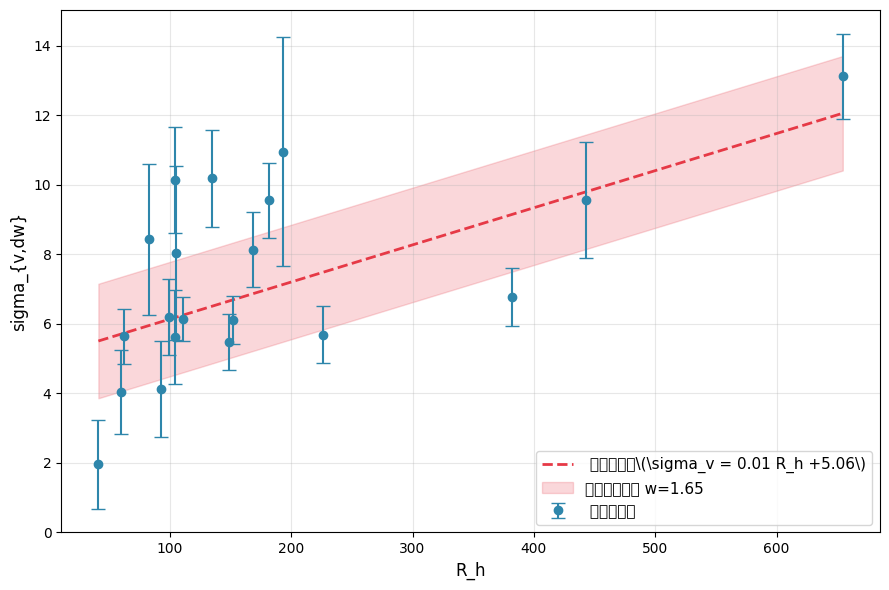

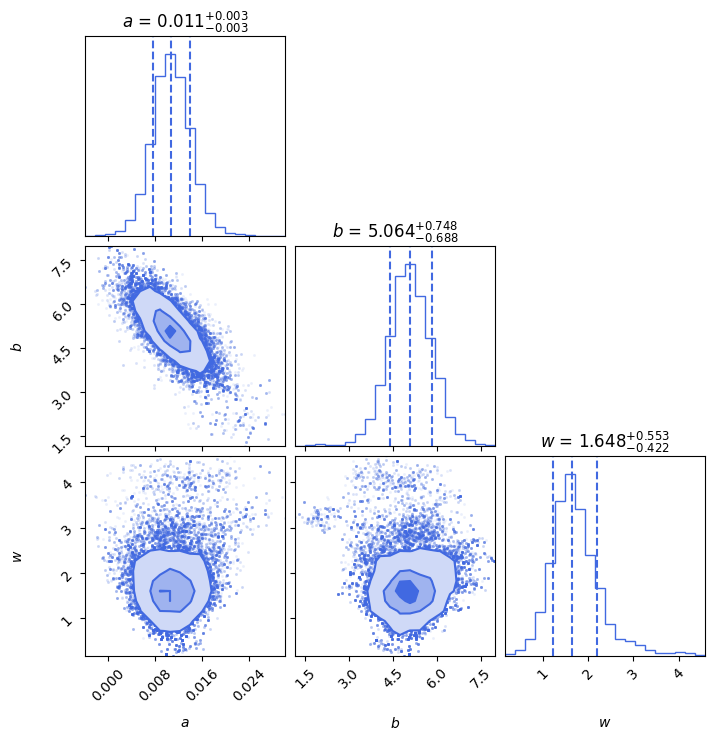

In [44]:
main()